<a href="https://colab.research.google.com/github/eljustus/Nigerian-Tribal-Name-Project/blob/main/Nigerian_Tribal_names_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas matplotlib pandas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import folium

In [ ]:
# Paste your modified CSV URL here
sheet_url = "https://docs.google.com/spreadsheets/d/1sNGWuk5kyEeEnl7gtpPedkVoCZtTWFqiSgv731v5KJY/export?format=csv&gid=1325515122"



In [ ]:
# Load directly into pandas DataFrame
df = pd.read_csv(sheet_url)

In [ ]:
df.head()

,ID,Timestamp,Tribal Name,Geo Region,State Found,Tribe,Name Meaning,Name Gender,IP Address,Current Residence,Created By
0,ab4527a6,11/21/2025 19:12:50,Omon,South-South,Edo,Bini,Child,Female,"6.636610, 3.260720",Nigeria,jenniferazenabor81@gmail.com
1,8d990ae5,11/21/2025 19:19:26,Eseohe,South-South,Edo,Esan,Gift,Female,"6.639272, 3.261663",Nigeria,jenniferazenabor81@gmail.com
2,33d013e5,11/21/2025 19:20:31,Osamudiamen,South-South,Edo,Esan,God stand by me,Male,"6.639272, 3.261663",Nigeria,jenniferazenabor81@gmail.com
3,4bcdbec7,11/21/2025 19:23:37,Iziegbe,South-South,Edo,Esan,Patience,Male,"6.636281, 3.260091",Nigeria,jenniferazenabor81@gmail.com
4,cf1d2b88,11/21/2025 19:25:00,Eromosele,South-South,Edo,Esan,God's Gift,Male,"6.635830, 3.261924",Nigeria,jenniferazenabor81@gmail.com


In [ ]:
df=df[["ID","Tribal Name","Geo Region","State Found","Tribe","Name Meaning","Name Gender"]]
df

,ID,Tribal Name,Geo Region,State Found,Tribe,Name Meaning,Name Gender
0,ab4527a6,Omon,South-South,Edo,Bini,Child,Female
1,8d990ae5,Eseohe,South-South,Edo,Esan,Gift,Female
2,33d013e5,Osamudiamen,South-South,Edo,Esan,God stand by me,Male
3,4bcdbec7,Iziegbe,South-South,Edo,Esan,Patience,Male
4,cf1d2b88,Eromosele,South-South,Edo,Esan,God's Gift,Male
...,...,...,...,...,...,...,...
662,ad94d1b4,Ochioha,South-East,Imo,Igbo,Public /Community Leader,Both Gender
663,63e9b07a,Ogbuagu,South-East,Anambra,Igbo,Lion Killer,Male
664,40dad833,Nneorah,South-East,Anambra,Igbo,Mother of all people,Female
665,a0b2cc35,Akudo,South-East,Anambra,Igbo,Wealth of peace,Both Gender


In [ ]:
df.ID.count()

np.int64(667)

In [ ]:
# Assuming your column is called 'Tribe' or 'Tribal Name' – change as needed
# Count occurrences of each tribe
tribe_counts = df['Tribe'].value_counts().reset_index()
tribe_counts.columns = ['Tribe', 'Count']
print(tribe_counts)

     Tribe  Count
0     Igbo    131
1    Isoko     68
2   Yoruba     64
3   Urhobo     57
4   Etsako     31
..     ...    ...
81    Geji      1
82   Burak      1
83    Rubu      1
84    Bade      1
85  Jimbin      1

[86 rows x 2 columns]


In [ ]:
# Top 10 tribes
print(tribe_counts.head(10))

          Tribe  Count
0          Igbo    131
1         Isoko     68
2        Yoruba     64
3        Urhobo     57
4        Etsako     31
5  Fula(Fulani)     24
6           Ika     22
7          Esan     22
8         Bette     18
9           Tiv     15


In [ ]:
# Group by Geo Region and count unique tribes
geo_tribe = df.groupby('Geo Region')['Tribe'].nunique().sort_values(ascending=False)
print(geo_tribe)

Geo Region
North-East     35
South-South    22
Middle-Belt    21
North-West      9
South-East      8
South-West      5
Name: Tribe, dtype: int64


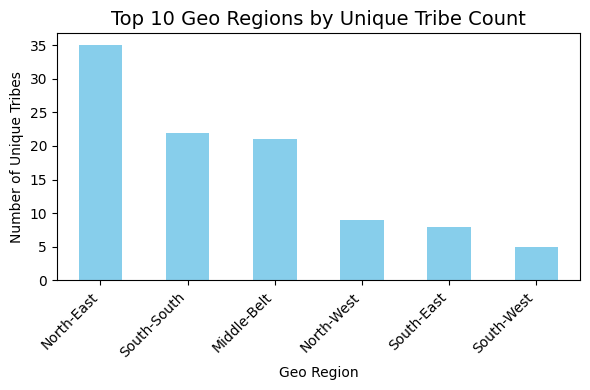

In [ ]:
# Assuming geo_tribe is a Series (e.g., df.groupby('Geo Region')['Tribe'].nunique())
geo_tribe.head(10).plot(kind='bar', figsize=(6,4), color='skyblue')

plt.title('Top 10 Geo Regions by Unique Tribe Count', fontsize=14)
plt.xlabel('Geo Region')
plt.ylabel('Number of Unique Tribes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

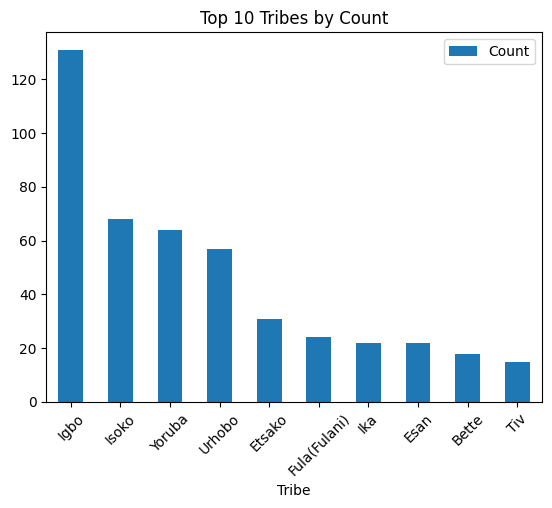

In [ ]:
##Basic visualization

tribe_counts.head(10).plot(kind='bar', x='Tribe', y='Count', title='Top 10 Tribes by Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
state= df[["State Found"]]
state.count()

,0
State Found,667


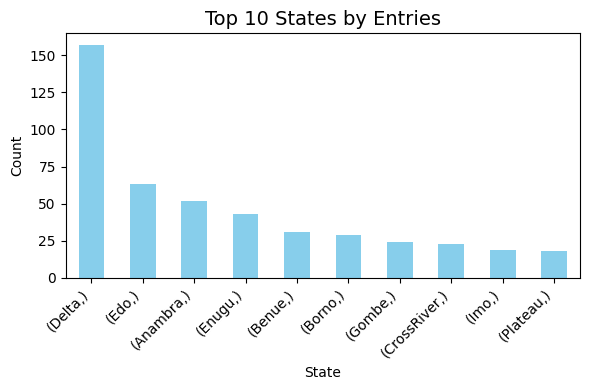

In [ ]:
Top_state = state.value_counts().head(10)
Top_state.plot(kind='bar', figsize=(6,4), color='skyblue')
plt.title('Top 10 States by Entries', fontsize=14)
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,ID,Tribal Name,Geo Region,State Found,Tribe,Name Meaning,Name Gender
0,ab4527a6,Omon,South-South,Edo,Bini,Child,Female
1,8d990ae5,Eseohe,South-South,Edo,Esan,Gift,Female
2,33d013e5,Osamudiamen,South-South,Edo,Esan,God stand by me,Male
3,4bcdbec7,Iziegbe,South-South,Edo,Esan,Patience,Male
4,cf1d2b88,Eromosele,South-South,Edo,Esan,God's Gift,Male


In [ ]:
# Clean column names (important!)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('\n', '')

print("Columns loaded:", df.columns.tolist())
print("First few rows:\n", df.head())

Columns loaded: ['id', 'tribal_name', 'geo_region', 'state_found', 'tribe', 'name_meaning', 'name_gender']
First few rows:
          id  tribal_name   geo_region state_found tribe     name_meaning  \
0  ab4527a6         Omon  South-South         Edo  Bini            Child   
1  8d990ae5       Eseohe  South-South         Edo  Esan             Gift   
2  33d013e5  Osamudiamen  South-South         Edo  Esan  God stand by me   
3  4bcdbec7      Iziegbe  South-South         Edo  Esan         Patience   
4  cf1d2b88    Eromosele  South-South         Edo  Esan       God's Gift   

  name_gender  
0      Female  
1      Female  
2        Male  
3        Male  
4        Male  


In [ ]:
# === Step 2: Aggregate data by State Found ===
# Option A: Count total entries per state (most common for choropleth)
state_counts = df['state_found'].value_counts().reset_index()
state_counts.columns = ['state_found', 'count']

In [ ]:
# Use state_counts for now (change to unique_tribes if preferred)
agg_df = state_counts

In [ ]:
# === Step 3: Load Nigeria states GeoJSON (reliable source) ===
geo_url = "https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/NGA/ADM1/geoBoundaries-NGA-ADM1.geojson"
nigeria = gpd.read_file(geo_url)

In [ ]:
# Print available state names in GeoJSON for matching
print("GeoJSON state names:", nigeria['shapeName'].unique())


GeoJSON state names: ['Cross River' 'Abuja Federal Capital Territory' 'Ogun' 'Oyo' 'Sokoto'
 'Zamfara' 'Lagos' 'Akwa Ibom' 'Bayelsa' 'Ondo' 'Delta' 'Rivers' 'Kwara'
 'Kogi' 'Benue' 'Borno' 'Katsina' 'Plateau' 'Edo' 'Jigawa' 'Anambra'
 'Kano' 'Nasarawa' 'Kebbi' 'Imo' 'Gombe' 'Adamawa' 'Yobe' 'Abia' 'Ekiti'
 'Osun' 'Bauchi' 'Niger' 'Kaduna' 'Enugu' 'Taraba' 'Ebonyi']


In [ ]:
merged = nigeria.merge(agg_df, left_on='shapeName', right_on='state_found', how='left')
merged['count'] = merged['count'].fillna(0)  # States with 0 get no color

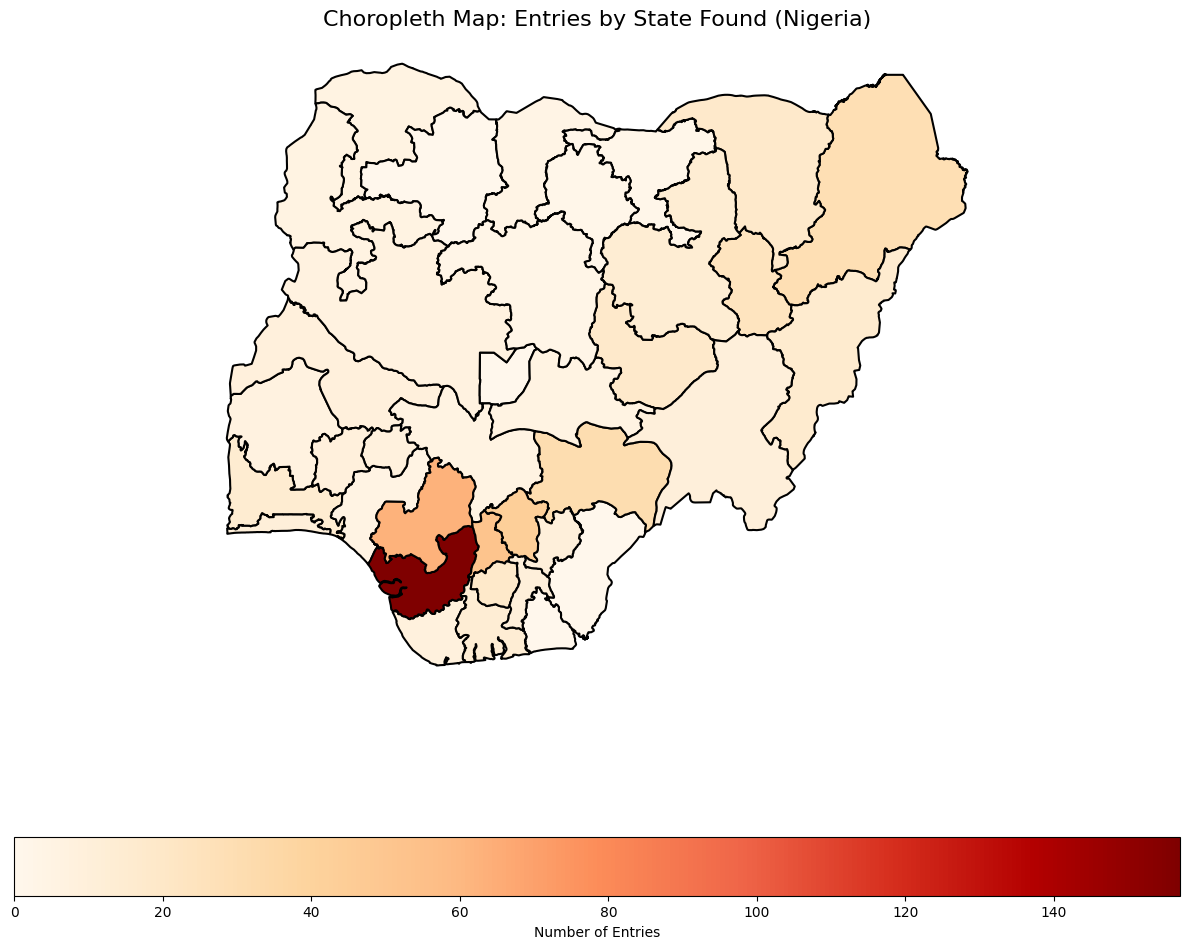

In [ ]:
##step 5: Plot the choropleth map ===
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

merged.plot(
    column='count',
    ax=ax,
    legend=True,
    cmap='OrRd',  # Orange-Red gradient; try 'Blues', 'YlOrRd', etc.
    edgecolor='black',
    linewidth=1.5,  # Bold borders
    legend_kwds={'label': "Number of Entries", 'orientation': "horizontal"}
)

ax.set_title('Choropleth Map: Entries by State Found (Nigeria)', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

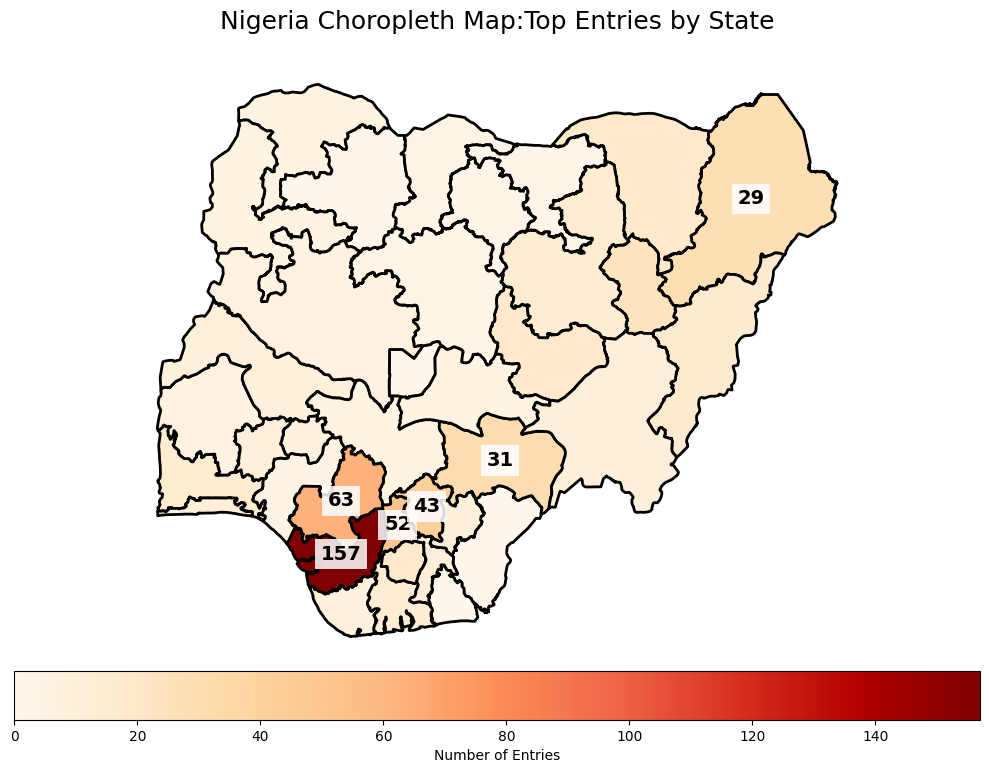

Map saved as 'nigeria_choropleth_labels_50plus.png'


<Figure size 640x480 with 0 Axes>

In [ ]:
###Python# === Step 5: Plot the choropleth map with labels ONLY for states >= 50 entries ===

fig, ax = plt.subplots(1, 1, figsize=(10, 8))  # Bigger size for better visibility
# Plot the base choropleth (all states shaded by count)
merged.plot(
    column='count',
    ax=ax,
    legend=True,
    cmap='OrRd',                  # Orange-Red gradient (darker = higher count)
    edgecolor='black',
    linewidth=2.0,                # Bold black borders
    missing_kwds={"color": "lightgrey", "hatch": "///"},  # Optional: pattern for 0
    legend_kwds={'label': "Number of Entries", 'orientation': "horizontal", 'pad': 0.01}
)

# Add count labels ONLY for states with count >= 25
for idx, row in merged.iterrows():
    if row['count'] >= 25:
        # Get centroid (center) of the state polygon
        centroid = row.geometry.centroid

        # Annotate the count number (large, bold, white background for readability)
        ax.annotate(
            text=str(int(row['count'])),  # e.g., "156"
            xy=(centroid.x, centroid.y),
            xytext=(0, 0),
            textcoords="offset points",
            ha='center', va='center',
            fontsize=14,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=4)
        )

# Final touches
ax.set_title('Nigeria Choropleth Map:Top Entries by State', fontsize=18, pad=20)
ax.set_axis_off()  # Hide axes for clean map look
plt.tight_layout()

# Show the map
plt.show()

# Optional: Save high-quality image
plt.savefig('nigeria_choropleth_labels_50plus.png', dpi=300, bbox_inches='tight')
print("Map saved as 'nigeria_choropleth_labels_50plus.png'")

In [ ]:
plt.savefig('nigeria_choropleth_map.png', dpi=300, bbox_inches='tight')
print("Map saved as nigeria_choropleth_map.png")

Map saved as nigeria_choropleth_map.png


<Figure size 640x480 with 0 Axes>

In [ ]:
!ls

nigeria_choropleth_labels_50plus.png  nigeria_choropleth_map.png  sample_data


In [ ]:
from google.colab import files
files.download("nigeria_choropleth_map.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
m =folium.map('nigeria_choropleth_map.png')
folium.Choropleth('nigeria_choropleth_map.png').add_to(m)
m.save("Tribal_names_collection.html")

NameError: name 'nigeria_choropleth_map' is not defined